<a href="https://colab.research.google.com/github/vasudhabobde/Machine_Learning_Practicals/blob/main/B3_B2_32_MLDS_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("Purchase Behavior.csv")
df

,User ID,Gender,Total no of Product,Amount
0,15624510,Male,19,19000
1,15810944,Male,35,20000
2,15668575,Female,26,43000
3,15603246,Female,27,57000
4,15804002,Male,19,76000
...,...,...,...,...
395,15691863,Female,46,41000
396,15706071,Male,51,23000
397,15654296,Female,50,20000
398,15755018,Male,36,33000


In [ ]:
print(df.columns)

Index(['User ID', 'Gender', 'Total no of Product', 'Amount'], dtype='object')


In [ ]:
print(df.head())

    User ID  Gender  Total no of Product  Amount
0  15624510    Male                   19   19000
1  15810944    Male                   35   20000
2  15668575  Female                   26   43000
3  15603246  Female                   27   57000
4  15804002    Male                   19   76000


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt



X = df[["Amount", "Total no of Product"]]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())

    User ID  Gender  Total no of Product  Amount  Cluster
0  15624510       0                   19   19000        2
1  15810944       0                   35   20000        2
2  15668575       1                   26   43000        2
3  15603246       1                   27   57000        2
4  15804002       0                   19   76000        2


In [ ]:
features = ["Gender", "Total no of Product", "Amount"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[-1.02020406 -1.78179743 -1.49004624]
 [-1.02020406 -0.25358736 -1.46068138]
 [ 0.98019606 -1.11320552 -0.78528968]
 [ 0.98019606 -1.01769239 -0.37418169]
 [-1.02020406 -1.78179743  0.18375059]]


In [ ]:
initial_indices = [0, 1, 2]
initial_centroids = X_scaled[initial_indices]
print("Initial Centroids:")
print(initial_centroids)

Initial Centroids:
[[-1.02020406 -1.78179743 -1.49004624]
 [-1.02020406 -0.25358736 -1.46068138]
 [ 0.98019606 -1.11320552 -0.78528968]]


In [ ]:
initial_indices = [0, 1, 2]
initial_centroids = X_scaled[initial_indices]
print("Initial Centroids:")
print(initial_centroids)

Initial Centroids:
[[-1.02020406 -1.78179743 -1.49004624]
 [-1.02020406 -0.25358736 -1.46068138]
 [ 0.98019606 -1.11320552 -0.78528968]]


In [ ]:
amount_index = 2
product_index = 1
plt.figure(figsize=(9, 6))

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

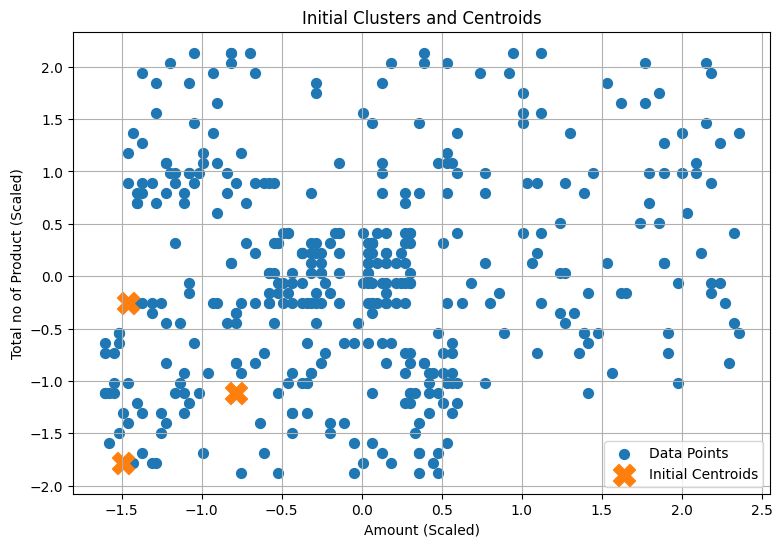

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_scaled[:, amount_index],
    X_scaled[:, product_index],
    s=50,
    label="Data Points"
)
plt.scatter(
    initial_centroids[:, amount_index],
    initial_centroids[:, product_index],
    marker="X",
    s=250,
    label="Initial Centroids"
)

plt.xlabel("Amount (Scaled)")
plt.ylabel("Total no of Product (Scaled)")
plt.title("Initial Clusters and Centroids")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    init=initial_centroids,
    n_init=1,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())

    User ID  Gender  Total no of Product  Amount  Cluster
0  15624510       0                   19   19000        0
1  15810944       0                   35   20000        1
2  15668575       1                   26   43000        0
3  15603246       1                   27   57000        0
4  15804002       0                   19   76000        0


In [ ]:
final_centroids = kmeans.cluster_centers_

print("Final Centroids:")
print(final_centroids)

Final Centroids:
[[ 0.36007202 -1.09696829 -0.63317972]
 [-1.02020406  0.1579874   0.09227461]
 [ 0.98019606  0.61947339  0.35624193]]


In [ ]:
final_centroids_original = scaler.inverse_transform(final_centroids)

centroid_df = pd.DataFrame(
    final_centroids_original,
    columns=features
)

print("Final Centroids in Original Units:")
print(centroid_df)

Final Centroids in Original Units:
         Gender  Total no of Product        Amount
0  6.900000e-01            26.170000  48180.000000
1  4.440892e-16            39.309091  72884.848485
2  1.000000e+00            44.140741  81874.074074


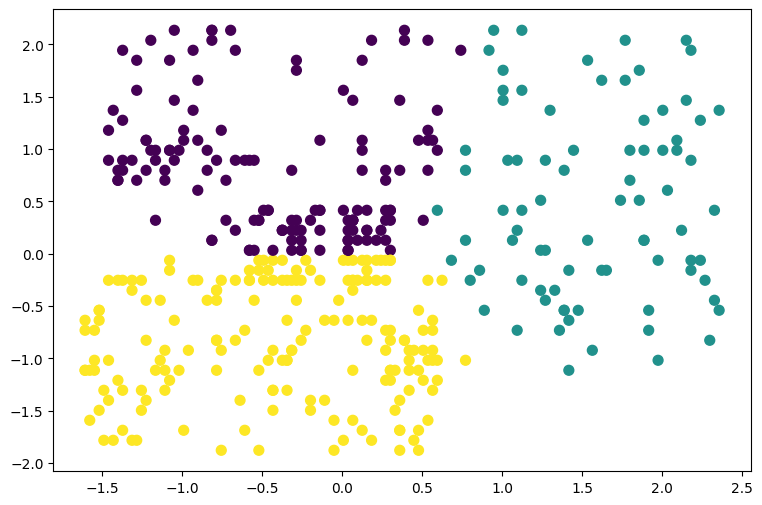

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_scaled[:, amount_index],
    X_scaled[:, product_index],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)


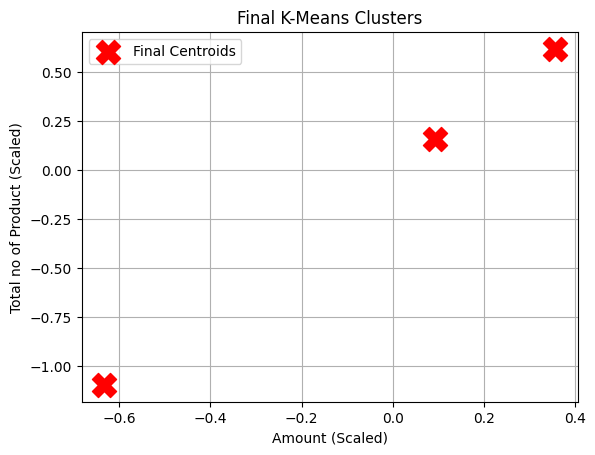

In [ ]:
# Final centroids
plt.scatter(
    final_centroids[:, amount_index],
    final_centroids[:, product_index],
    marker="X",
    s=300,
    color="red",
    label="Final Centroids"
)

plt.xlabel("Amount (Scaled)")
plt.ylabel("Total no of Product (Scaled)")
plt.title("Final K-Means Clusters")
plt.legend()
plt.grid(True)

plt.show()

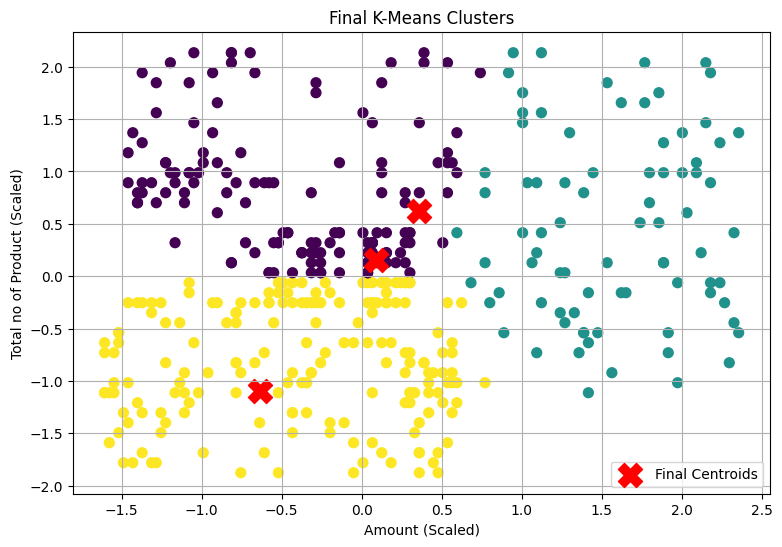

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_scaled[:, amount_index],
    X_scaled[:, product_index],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)
plt.scatter(
    final_centroids[:, amount_index],
    final_centroids[:, product_index],
    marker="X",
    s=300,
    color="red",
    label="Final Centroids"
)

plt.xlabel("Amount (Scaled)")
plt.ylabel("Total no of Product (Scaled)")
plt.title("Final K-Means Clusters")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
print(df["Cluster"].value_counts().sort_index())


Cluster
0    100
1    165
2    135
Name: count, dtype: int64


In [ ]:
cluster_summary = df.groupby("Cluster")[
    ["Gender", "Total no of Product", "Amount"]
].mean()

print(cluster_summary)

         Gender  Total no of Product        Amount
Cluster                                           
0          0.69            26.170000  48180.000000
1          0.00            39.309091  72884.848485
2          1.00            44.140741  81874.074074
